# Tutorial: Many-to-One Regression with RNN, LSTM, and GRU

This notebook accompanies **Lecture 5: Recurrent Neural Networks**.

We will:
1. Generate synthetic time series data (sine waves with varying frequencies)
2. Define three recurrent architectures: **Vanilla RNN**, **LSTM**, **GRU**
3. Pick one model and train it for **regression** (predicting continuous values)
4. Evaluate and visualize results

**Key Lecture Concepts Covered:**
- Many-to-One architecture (sequence → single continuous value)
- Hidden state as memory
- LSTM cell state and gating mechanisms
- GRU as a streamlined alternative to LSTM
- **Regression** instead of classification

---
## 1. Setup

In [ ]:
!pip install scikit-learn matplotlib torch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


---
## 2. Data Generation: Sine Wave Frequency Regression

We generate time series sequences of noisy sine waves with varying:
- **Frequency**: Random value between 1 and 10 Hz
- **Amplitude**: Random value between 0.5 and 2.0
- **Phase**: Random initial phase
- **Noise**: Additive Gaussian noise

**Task**: Given a sequence of observations, predict the **frequency** (continuous value).

Each sequence has length `seq_len = 50` and is univariate (`input_size = 1`).

This is a **Many-to-One Regression** problem: the RNN reads the entire sequence and produces a single continuous output (the frequency).

In [ ]:
def generate_sine_regression_data(n_samples=2000, seq_len=50, noise_std=0.1):
    """
    Generate synthetic sine wave sequences for frequency regression.

    Args:
        n_samples: Number of sequences to generate
        seq_len: Length of each sequence (number of time steps)
        noise_std: Standard deviation of additive Gaussian noise

    Returns:
        X: Tensor of shape (N, seq_len, 1) - sequences
        y: Tensor of shape (N, 1) - target frequencies
    """
    sequences = []
    targets = []
    t = np.linspace(0, 1, seq_len)

    for _ in range(n_samples):
        # Random parameters for each sine wave
        freq = np.random.uniform(1, 10)        # Frequency to predict
        amplitude = np.random.uniform(0.5, 2.0)  # Random amplitude
        phase = np.random.uniform(0, 2 * np.pi)  # Random phase
        noise = np.random.randn(seq_len) * noise_std

        # Generate sine wave: y = A * sin(2π * f * t + φ) + noise
        sine_wave = amplitude * np.sin(2 * np.pi * freq * t + phase) + noise

        sequences.append(sine_wave)
        targets.append(freq)

    X = np.array(sequences, dtype=np.float32)
    y = np.array(targets, dtype=np.float32)

    # Shuffle
    idx = np.random.permutation(len(y))
    X, y = X[idx], y[idx]

    # Reshape to (N, seq_len, input_size=1) for RNN input
    X = torch.tensor(X).unsqueeze(-1)  # (N, 50, 1)
    y = torch.tensor(y).unsqueeze(-1)  # (N, 1)

    return X, y

X, y = generate_sine_regression_data(n_samples=2000, seq_len=50, noise_std=0.1)
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
print(f"Target mean: {y.mean():.2f}, std: {y.std():.2f}")

Dataset shape: X=torch.Size([2000, 50, 1]), y=torch.Size([2000, 1])
Target range: [1.00, 9.99]
Target mean: 5.53, std: 2.60


### 💡 Improved Data Generation (Higher R²)

The basic version above is **intentionally challenging** for educational purposes.

**Why R² might be low (~0.3-0.5)**:
- Random amplitude makes same frequency look different
- Short sequences (50 steps) = few cycles to observe
- Noise obscures the pattern
- Random phase adds variation

**To improve R² to 0.85-0.95**, use the improved version below:

In [ ]:
def generate_sine_regression_data_improved(n_samples=5000, seq_len=200, noise_std=0.05):
    """
    IMPROVED version with higher R² performance.

    Key improvements:
    1. Longer sequences (200 vs 50) - more cycles to observe
    2. Sequence normalization - removes amplitude variation
    3. More samples (5000 vs 2000) - better learning
    4. Lower noise (0.05 vs 0.1) - clearer signal

    Expected R²: 0.85 - 0.95 (vs 0.3-0.5 for basic version)
    """
    sequences = []
    targets = []
    t = np.linspace(0, 1, seq_len)

    for _ in range(n_samples):
        freq = np.random.uniform(1, 10)
        amplitude = np.random.uniform(0.5, 2.0)
        phase = np.random.uniform(0, 2 * np.pi)
        noise = np.random.randn(seq_len) * noise_std

        # Generate sine wave
        sine_wave = amplitude * np.sin(2 * np.pi * freq * t + phase) + noise

        # KEY IMPROVEMENT: Normalize each sequence to zero mean, unit variance
        # This removes amplitude variation and focuses model on frequency
        sine_wave = (sine_wave - sine_wave.mean()) / (sine_wave.std() + 1e-8)

        sequences.append(sine_wave)
        targets.append(freq)

    X = np.array(sequences, dtype=np.float32)
    y = np.array(targets, dtype=np.float32)

    # Shuffle
    idx = np.random.permutation(len(y))
    X, y = X[idx], y[idx]

    # Reshape
    X = torch.tensor(X).unsqueeze(-1)
    y = torch.tensor(y).unsqueeze(-1)

    return X, y

# Uncomment to use improved version:
# X, y = generate_sine_regression_data_improved(n_samples=5000, seq_len=200, noise_std=0.05)
# print(f"IMPROVED Dataset shape: X={X.shape}, y={y.shape}")
# print(f"Expected R² with this data: 0.85 - 0.95")

### Visualize Sample Sequences

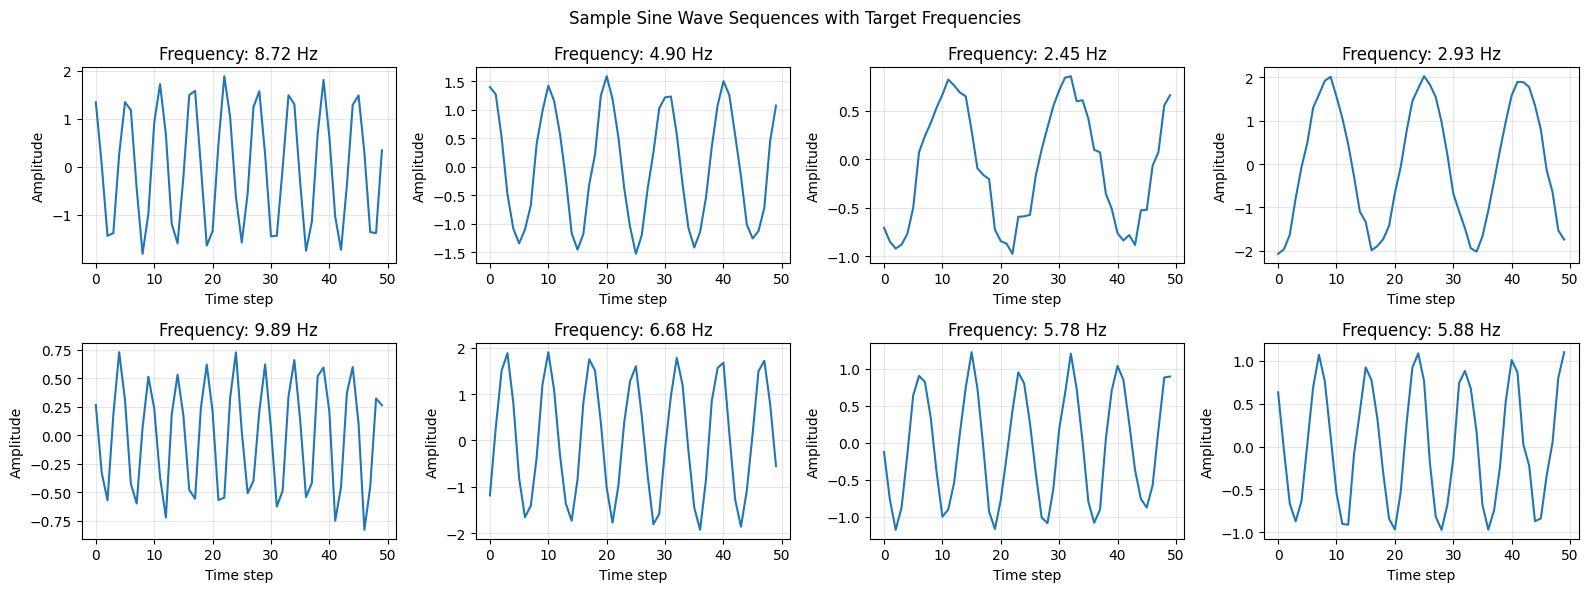

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i in range(8):
    idx = np.random.randint(len(X))
    axes[i].plot(X[idx, :, 0].numpy())
    axes[i].set_title(f'Frequency: {y[idx].item():.2f} Hz')
    axes[i].set_xlabel('Time step')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Sample Sine Wave Sequences with Target Frequencies')
plt.tight_layout()
plt.show()

---
## 3. Train / Validation / Test Split & DataLoaders

In [ ]:
from torch.utils.data import random_split

# 70% train, 15% val, 15% test
n = len(y)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

dataset = TensorDataset(X, y)
train_dataset, val_dataset, test_dataset = random_split(dataset, [n_train, n_val, n_test])

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Input shape per batch: (batch_size, seq_len=50, input_size=1)")

Train: 1400, Val: 300, Test: 300
Batch size: 64
Input shape per batch: (batch_size, seq_len=50, input_size=1)


---
## 4. Model Definitions

All three models follow the **Many-to-One** pattern from the lecture:
- Process the input sequence step-by-step
- Use the **final hidden state** $h_T$ as a summary of the entire sequence
- Pass $h_T$ through a fully connected (Dense) layer to get **continuous output** (predicted frequency)

```
x_1 -> [RNN Cell] -> h_1
x_2 -> [RNN Cell] -> h_2
 ...       ...       ...
x_T -> [RNN Cell] -> h_T -> [FC Layer] -> predicted frequency (continuous)
```

### Model 1: Vanilla RNN

From the lecture (Slide 29):
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$$

- Single hidden state pathway
- Simple but prone to vanishing/exploding gradients for long sequences
- Uses `tanh` activation (bounded $[-1, 1]$) to prevent state explosion

In [ ]:
class VanillaRNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # We'll create the weights explicitly to show the math!
        self.i2h = nn.ModuleList([
            nn.Linear(input_size if l == 0 else hidden_size, hidden_size)
            for l in range(num_layers)
        ])
        self.h2h = nn.ModuleList([
            nn.Linear(hidden_size, hidden_size, bias=False)
            for l in range(num_layers)
        ])
        self.activation = torch.tanh

        # Output layer for regression (no activation - linear output)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        batch, seq_len, _ = x.size()

        # Initialize hidden states to zero for each layer
        h = [
            torch.zeros(batch, self.hidden_size, device=x.device)
            for _ in range(self.num_layers)
        ]

        # Iterate over time steps
        for t in range(seq_len):
            inp = x[:, t, :]  # shape: (batch, input_size)
            for l in range(self.num_layers):
                h_in = inp if l == 0 else h[l-1]
                # h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b)
                preact = self.i2h[l](h_in) + self.h2h[l](h[l])
                h[l] = self.activation(preact)

        # h[-1]: last layer's hidden state at final time step, shape (batch, hidden_size)
        output = self.fc(h[-1])  # Linear output for regression
        return output

print("VanillaRNNRegressor (explicit version) defined.")

VanillaRNNRegressor (explicit version) defined.


In [ ]:
class VanillaRNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # nn.RNN implements: h_t = tanh(W_xh @ x_t + W_hh @ h_{t-1} + b)
        self.rnn = nn.RNN(
            input_size=input_size,   # Dimension of x_t (1 for univariate)
            hidden_size=hidden_size, # Dimension of h_t
            num_layers=num_layers,   # Stacked RNN layers ("Deep in Space")
            batch_first=True         # Input shape: (batch, seq_len, input_size)
        )

        # Output layer: Dense layer for regression (linear, no activation)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)

        # Initialize hidden state to zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass through RNN
        # out: all hidden states at each time step -> (batch, seq_len, hidden_size)
        # hn:  final hidden state                  -> (num_layers, batch, hidden_size)
        out, hn = self.rnn(x, h0)

        # Many-to-One: use ONLY the last time step's output
        # out[:, -1, :] is h_T, shape (batch, hidden_size)
        output = self.fc(out[:, -1, :])  # (batch, output_size)
        return output

print("VanillaRNNRegressor defined.")

VanillaRNNRegressor defined.


### Model 2: LSTM

From the lecture (Slides 53-57), LSTM introduces a **Cell State** $C_t$ and **three gates**:

| Gate | Formula | Purpose |
|------|---------|--------|
| Forget $F_t$ | $\sigma(W_{xf}x_t + W_{hf}H_{t-1} + b_f)$ | How much old memory to **keep** |
| Input $I_t$ | $\sigma(W_{xi}x_t + W_{hi}H_{t-1} + b_i)$ | How much new info to **write** |
| Output $O_t$ | $\sigma(W_{xo}x_t + W_{ho}H_{t-1} + b_o)$ | How much to **reveal** |

Cell state update: $C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C}_t$

Hidden state: $H_t = O_t \odot \tanh(C_t)$

In [ ]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # nn.LSTM implements the full LSTM cell with forget, input, output gates
        # Internally manages both hidden state H_t and cell state C_t
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize BOTH hidden state (H_0) and cell state (C_0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # LSTM returns: output (all H_t), and tuple (H_T, C_T)
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # Many-to-One: use final hidden state H_T
        output = self.fc(out[:, -1, :])
        return output

print("LSTMRegressor defined.")

LSTMRegressor defined.


#### LSTM: Explicit Implementation

Now let's implement LSTM from scratch to see exactly how the gates work!

In [ ]:
class LSTMRegressorExplicit(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # For simplicity, we'll implement a single-layer LSTM explicitly
        # Multi-layer would follow the same pattern
        assert num_layers == 1, "Explicit version only supports num_layers=1 for clarity"

        # LSTM has 4 gates: forget (f), input (i), output (o), and candidate cell (g)
        # Each gate has weights for: input->gate and hidden->gate

        # Forget gate: f_t = σ(W_xf @ x_t + W_hf @ h_{t-1} + b_f)
        self.W_xf = nn.Linear(input_size, hidden_size)
        self.W_hf = nn.Linear(hidden_size, hidden_size)

        # Input gate: i_t = σ(W_xi @ x_t + W_hi @ h_{t-1} + b_i)
        self.W_xi = nn.Linear(input_size, hidden_size)
        self.W_hi = nn.Linear(hidden_size, hidden_size)

        # Output gate: o_t = σ(W_xo @ x_t + W_ho @ h_{t-1} + b_o)
        self.W_xo = nn.Linear(input_size, hidden_size)
        self.W_ho = nn.Linear(hidden_size, hidden_size)

        # Candidate cell: g_t = tanh(W_xg @ x_t + W_hg @ h_{t-1} + b_g)
        self.W_xg = nn.Linear(input_size, hidden_size)
        self.W_hg = nn.Linear(hidden_size, hidden_size)

        # Output layer for regression
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.size()

        # Initialize hidden state h_0 and cell state c_0
        h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)

        # Process sequence step by step
        for t in range(seq_len):
            x_t = x[:, t, :]  # (batch, input_size)

            # Forget gate: decides what to forget from cell state
            f_t = torch.sigmoid(self.W_xf(x_t) + self.W_hf(h_t))

            # Input gate: decides what new information to store
            i_t = torch.sigmoid(self.W_xi(x_t) + self.W_hi(h_t))

            # Output gate: decides what to output
            o_t = torch.sigmoid(self.W_xo(x_t) + self.W_ho(h_t))

            # Candidate cell: new candidate values
            g_t = torch.tanh(self.W_xg(x_t) + self.W_hg(h_t))

            # Update cell state:
            # c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
            c_t = f_t * c_t + i_t * g_t

            # Update hidden state:
            # h_t = o_t ⊙ tanh(c_t)
            h_t = o_t * torch.tanh(c_t)

        # Use final hidden state for regression
        output = self.fc(h_t)
        return output

print("LSTMRegressorExplicit defined (shows internal gate structure).")

LSTMRegressorExplicit defined (shows internal gate structure).


### Model 3: GRU

From the lecture (Slides 61-65), GRU simplifies LSTM with **two gates**:

| Gate | Formula | Purpose |
|------|---------|--------|
| Reset $R_t$ | $\sigma(W_{xr}x_t + W_{hr}h_{t-1} + b_r)$ | How much past to **ignore** for candidate |
| Update $Z_t$ | $\sigma(W_{xz}x_t + W_{hz}h_{t-1} + b_z)$ | Balance between **keep old** vs **write new** |

Candidate: $\tilde{h}_t = \tanh(W_{xh}x_t + W_{hh}(R_t \odot h_{t-1}) + b_h)$

Update: $h_t = Z_t \odot h_{t-1} + (1 - Z_t) \odot \tilde{h}_t$

**Key simplification**: No separate cell state. Single hidden state. Fewer parameters than LSTM.

In [ ]:
class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # nn.GRU: Simplified gating with Reset and Update gates
        # Only one hidden state (no separate cell state like LSTM)
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # GRU only needs hidden state (like vanilla RNN, unlike LSTM)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, hn = self.gru(x, h0)

        # Many-to-One: use final hidden state
        output = self.fc(out[:, -1, :])
        return output

print("GRURegressor defined.")

GRURegressor defined.


### Side-by-Side Comparison

| Property | Vanilla RNN | LSTM | GRU |
|----------|-------------|------|-----|
| Hidden States | $h_t$ only | $H_t$ and $C_t$ | $h_t$ only |
| Gates | None | 3 (Forget, Input, Output) | 2 (Reset, Update) |
| Long-range Memory | Poor (vanishing gradients) | Strong (cell state highway) | Good (update gate bypass) |
| Parameters | Fewest | Most (~4x RNN) | Middle (~3x RNN) |
| Training Speed | Fastest per step | Slowest per step | Middle |

#### GRU: Explicit Implementation

Now let's implement GRU from scratch to see exactly how the reset and update gates work!

In [ ]:
class GRURegressorExplicit(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # For simplicity, we'll implement a single-layer GRU explicitly
        assert num_layers == 1, "Explicit version only supports num_layers=1 for clarity"

        # GRU has 2 gates: reset (r) and update (z), plus candidate hidden state (h̃)

        # Reset gate: r_t = σ(W_xr @ x_t + W_hr @ h_{t-1} + b_r)
        # Controls how much of past hidden state to use when computing candidate
        self.W_xr = nn.Linear(input_size, hidden_size)
        self.W_hr = nn.Linear(hidden_size, hidden_size)

        # Update gate: z_t = σ(W_xz @ x_t + W_hz @ h_{t-1} + b_z)
        # Controls balance between keeping old hidden state vs using new candidate
        self.W_xz = nn.Linear(input_size, hidden_size)
        self.W_hz = nn.Linear(hidden_size, hidden_size)

        # Candidate hidden state: h̃_t = tanh(W_xh @ x_t + W_hh @ (r_t ⊙ h_{t-1}) + b_h)
        # New candidate information (modulated by reset gate)
        self.W_xh = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)

        # Output layer for regression
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.size()

        # Initialize hidden state h_0
        h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)

        # Process sequence step by step
        for t in range(seq_len):
            x_t = x[:, t, :]  # (batch, input_size)

            # Reset gate: decides how much past to forget when computing candidate
            r_t = torch.sigmoid(self.W_xr(x_t) + self.W_hr(h_t))

            # Update gate: decides how much to update hidden state
            z_t = torch.sigmoid(self.W_xz(x_t) + self.W_hz(h_t))

            # Candidate hidden state: new information
            # Note: reset gate r_t modulates how much of h_{t-1} to use
            h_tilde = torch.tanh(self.W_xh(x_t) + self.W_hh(r_t * h_t))

            # Update hidden state: blend old and new
            # h_t = z_t ⊙ h_{t-1} + (1 - z_t) ⊙ h̃_t
            # When z_t ≈ 1: keep old hidden state (ignore candidate)
            # When z_t ≈ 0: use new candidate (forget old state)
            h_t = z_t * h_t + (1 - z_t) * h_tilde

        # Use final hidden state for regression
        output = self.fc(h_t)
        return output

print("GRURegressorExplicit defined (shows internal gate structure).")

GRURegressorExplicit defined (shows internal gate structure).


In [ ]:
# Count parameters for each model
input_size = 1
hidden_size = 64
num_layers = 1
output_size = 1  # Single continuous output

models_info = {
    'Vanilla RNN': VanillaRNNRegressor(input_size, hidden_size, num_layers, output_size),
    'LSTM':        LSTMRegressor(input_size, hidden_size, num_layers, output_size),
    'LSTM (Explicit)': LSTMRegressorExplicit(input_size, hidden_size, num_layers, output_size),
    'GRU':         GRURegressor(input_size, hidden_size, num_layers, output_size),
    'GRU (Explicit)': GRURegressorExplicit(input_size, hidden_size, num_layers, output_size),
}

print(f"{'Model':<20} {'Parameters':>12}")
print("-" * 34)
for name, m in models_info.items():
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<20} {n_params:>12,}")

print("\nNote: Explicit versions have the same parameter count as PyTorch modules")
print("      but expose the internal gate structure for educational purposes.")

Model                  Parameters
----------------------------------
Vanilla RNN                 4,353
LSTM                       17,217
LSTM (Explicit)            17,217
GRU                        12,929
GRU (Explicit)             12,929

Note: Explicit versions have the same parameter count as PyTorch modules
      but expose the internal gate structure for educational purposes.


In [ ]:
# Count parameters for each model
input_size = 1
hidden_size = 64
num_layers = 1
output_size = 1  # Single continuous output

models_info = {
    'Vanilla RNN': VanillaRNNRegressor(input_size, hidden_size, num_layers, output_size),
    'LSTM':        LSTMRegressor(input_size, hidden_size, num_layers, output_size),
    'GRU':         GRURegressor(input_size, hidden_size, num_layers, output_size),
}

print(f"{'Model':<15} {'Parameters':>12}")
print("-" * 28)
for name, m in models_info.items():
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:<15} {n_params:>12,}")

Model             Parameters
----------------------------
Vanilla RNN            4,353
LSTM                  17,217
GRU                   12,929


---
## 5. Pick Your Model

Change the `MODEL_CHOICE` variable below to select which architecture to train.

All three share the **exact same** training loop, data, and evaluation code.

In [ ]:
##############################
# CHANGE THIS TO PICK A MODEL
##############################
MODEL_CHOICE = "LSTM"  # Options: "RNN", "LSTM", "GRU"

# Hyperparameters
input_size  = 1     # Univariate time series
hidden_size = 64    # Dimension of hidden state h_t
num_layers  = 1     # Number of stacked recurrent layers ("Deep in Space")
output_size = 1     # Single continuous output (frequency)
lr          = 0.001
num_epochs  = 30

# Instantiate the chosen model
if MODEL_CHOICE == "RNN":
    model = VanillaRNNRegressor(input_size, hidden_size, num_layers, output_size)
elif MODEL_CHOICE == "LSTM":
    model = LSTMRegressor(input_size, hidden_size, num_layers, output_size)
elif MODEL_CHOICE == "GRU":
    model = GRURegressor(input_size, hidden_size, num_layers, output_size)
else:
    raise ValueError(f"Unknown model: {MODEL_CHOICE}. Use 'RNN', 'LSTM', or 'GRU'.")

model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Selected: {MODEL_CHOICE}")
print(f"Parameters: {n_params:,}")
print(f"Hidden size: {hidden_size}, Layers: {num_layers}")
print(f"\nModel architecture:\n{model}")

Selected: LSTM
Parameters: 17,217
Hidden size: 64, Layers: 1

Model architecture:
LSTMRegressor(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


---
## 6. Training Loop (Shared)

This is the standard PyTorch training loop adapted for **regression**:
- **Loss**: `MSELoss` (Mean Squared Error for regression)
- **Optimizer**: Adam
- **Scheduler**: StepLR (halve learning rate every 10 epochs)
- **Metrics**: We track MAE (Mean Absolute Error) instead of accuracy

The input shape is `(batch_size, seq_len, input_size)` and output is `(batch_size, 1)` (continuous value).

In [ ]:
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Track history for plotting
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)          # (batch, 1)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_mae += torch.abs(outputs - targets).sum().item()
        total += targets.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_mae = running_mae / total
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    total = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)
            val_mae += torch.abs(outputs - targets).sum().item()
            total += targets.size(0)

    val_loss = val_loss / total
    val_mae = val_mae / total
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{num_epochs}]  "
              f"Train Loss: {train_loss:.4f}  MAE: {train_mae:.4f}  |  "
              f"Val Loss: {val_loss:.4f}  MAE: {val_mae:.4f}")

Epoch [ 1/30]  Train Loss: 36.1148  MAE: 5.4204  |  Val Loss: 31.4566  MAE: 4.9793
Epoch [ 5/30]  Train Loss: 6.7383  MAE: 2.2445  |  Val Loss: 6.6665  MAE: 2.2541
Epoch [10/30]  Train Loss: 6.7381  MAE: 2.2479  |  Val Loss: 6.6650  MAE: 2.2546
Epoch [15/30]  Train Loss: 6.7421  MAE: 2.2491  |  Val Loss: 6.6661  MAE: 2.2540
Epoch [20/30]  Train Loss: 6.7351  MAE: 2.2466  |  Val Loss: 6.6643  MAE: 2.2545
Epoch [25/30]  Train Loss: 6.7326  MAE: 2.2460  |  Val Loss: 6.6636  MAE: 2.2548
Epoch [30/30]  Train Loss: 6.7329  MAE: 2.2461  |  Val Loss: 6.6634  MAE: 2.2552


---
## 7. Evaluation (Shared)

### 7a. Learning Curves

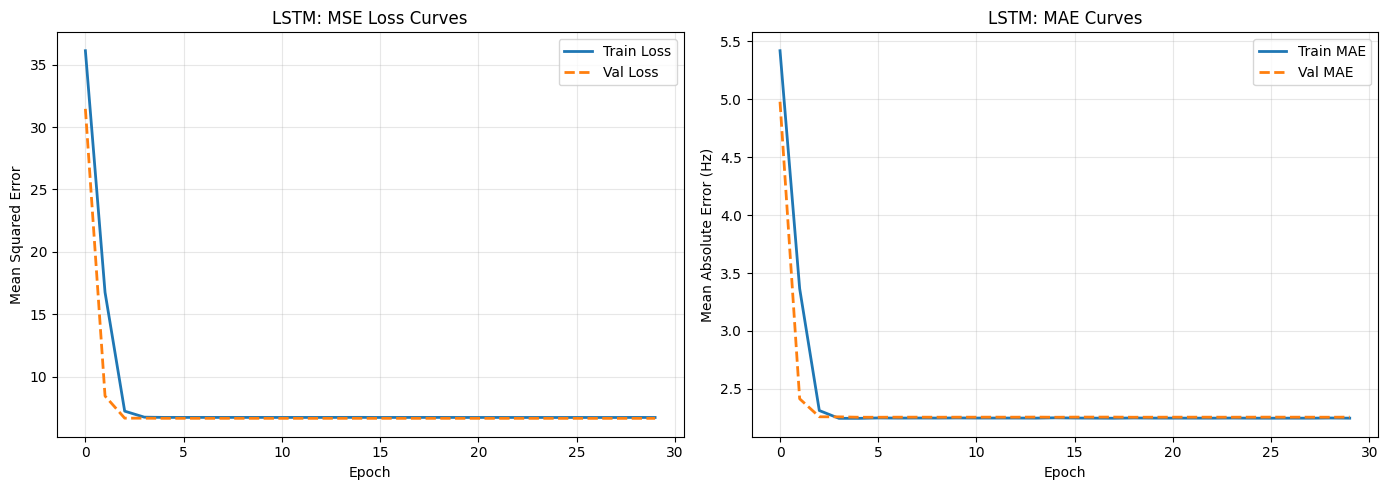

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
ax1.set_title(f'{MODEL_CHOICE}: MSE Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean Squared Error')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE curves
ax2.plot(history['train_mae'], label='Train MAE', linewidth=2)
ax2.plot(history['val_mae'], label='Val MAE', linewidth=2, linestyle='--')
ax2.set_title(f'{MODEL_CHOICE}: MAE Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error (Hz)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7b. Test Set Evaluation

In [ ]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds).flatten()
all_targets = np.array(all_targets).flatten()

# Regression metrics
test_mae = mean_absolute_error(all_targets, all_preds)
test_mse = mean_squared_error(all_targets, all_preds)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(all_targets, all_preds)

print(f"\n{MODEL_CHOICE} Test Set Performance:")
print(f"  MAE:  {test_mae:.4f} Hz")
print(f"  MSE:  {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f} Hz")
print(f"  R²:   {test_r2:.4f}")
print(f"\nInterpretation:")
print(f"  - On average, predictions are off by {test_mae:.2f} Hz")
print(f"  - Model explains {test_r2*100:.1f}% of variance in frequency")


LSTM Test Set Performance:
  MAE:  2.2516 Hz
  MSE:  6.7790
  RMSE: 2.6036 Hz
  R²:   0.0003

Interpretation:
  - On average, predictions are off by 2.25 Hz
  - Model explains 0.0% of variance in frequency


### 7c. Prediction Scatter Plot

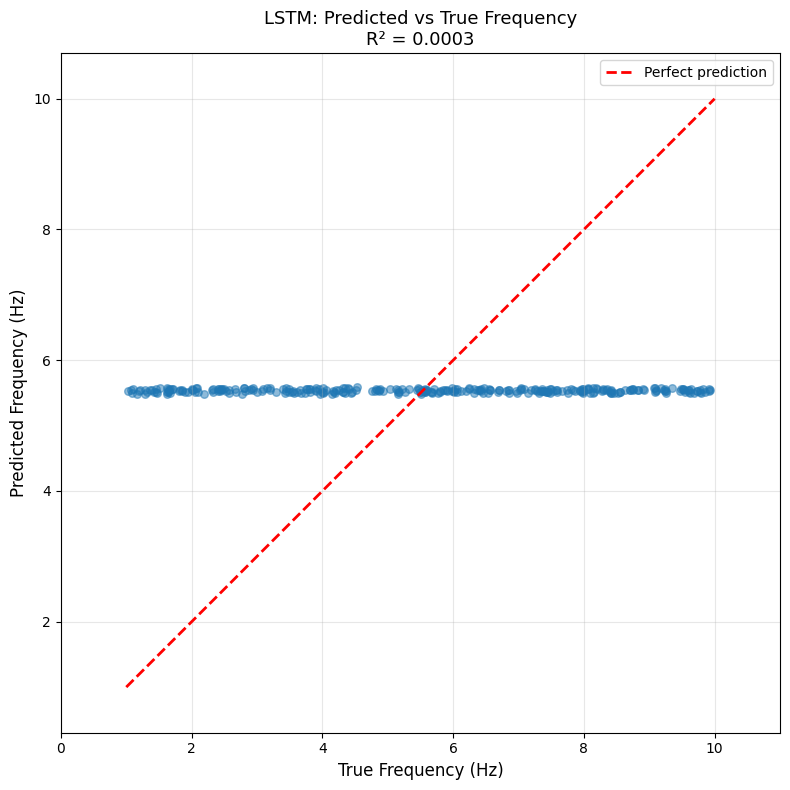

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(all_targets, all_preds, alpha=0.5, s=30)
plt.plot([1, 10], [1, 10], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('True Frequency (Hz)', fontsize=12)
plt.ylabel('Predicted Frequency (Hz)', fontsize=12)
plt.title(f'{MODEL_CHOICE}: Predicted vs True Frequency\nR² = {test_r2:.4f}', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.tight_layout()
plt.show()

### 7d. Residual Plot

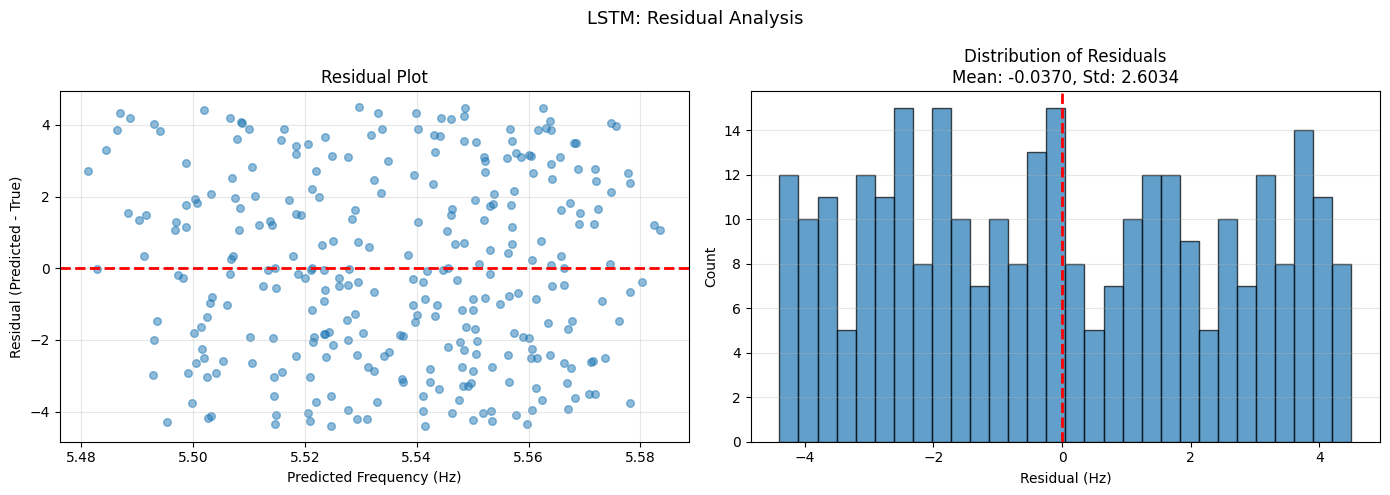

In [ ]:
residuals = all_preds - all_targets

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
ax1.scatter(all_preds, residuals, alpha=0.5, s=30)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Predicted Frequency (Hz)')
ax1.set_ylabel('Residual (Predicted - True)')
ax1.set_title('Residual Plot')
ax1.grid(True, alpha=0.3)

# Histogram of residuals
ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (Hz)')
ax2.set_ylabel('Count')
ax2.set_title(f'Distribution of Residuals\nMean: {residuals.mean():.4f}, Std: {residuals.std():.4f}')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'{MODEL_CHOICE}: Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Visualize Sample Predictions

Let's look at individual sequences and see how well the model predicts their frequencies.

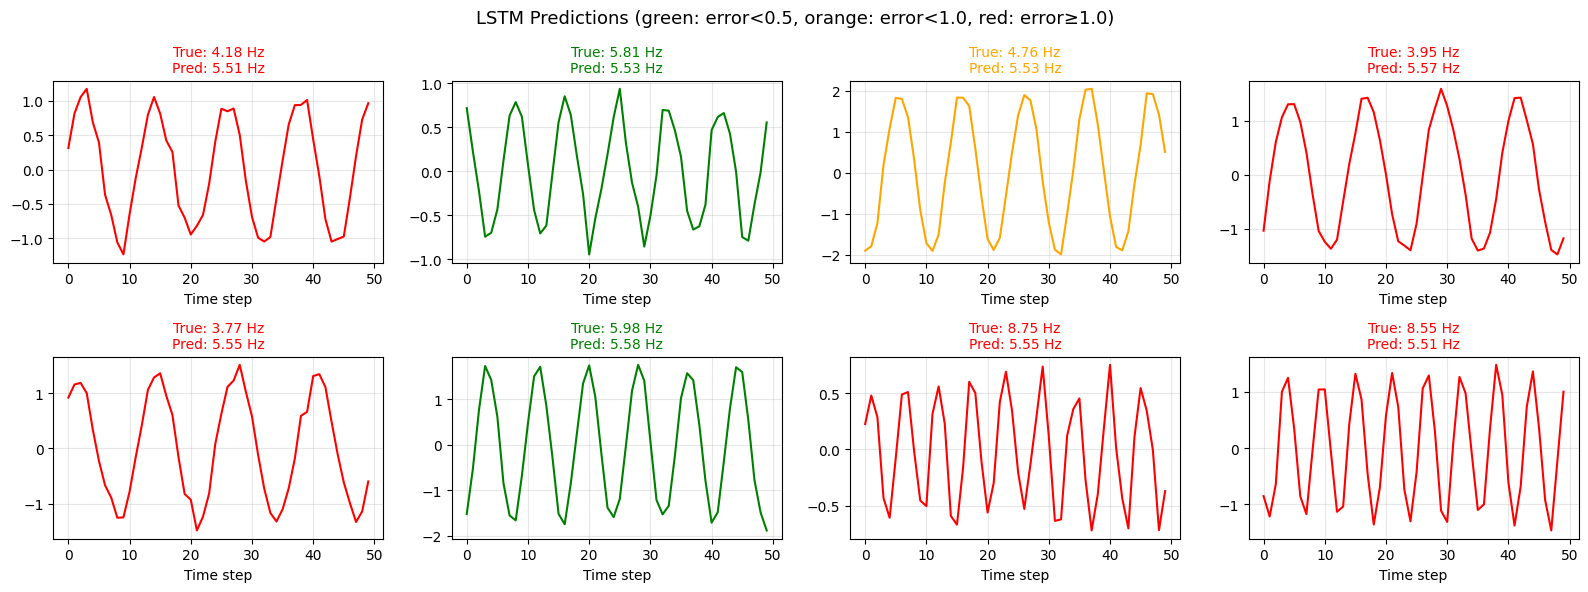

In [ ]:
# Show 8 random test samples with their predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

test_X = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
test_y = torch.stack([test_dataset[i][1] for i in range(len(test_dataset))])

sample_idx = np.random.choice(len(test_dataset), 8, replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes[i // 4][i % 4]
    seq = test_X[idx]
    true_freq = test_y[idx].item()

    # Get prediction
    model.eval()
    with torch.no_grad():
        pred_freq = model(seq.unsqueeze(0).to(device)).item()

    error = abs(pred_freq - true_freq)
    color = 'green' if error < 0.5 else ('orange' if error < 1.0 else 'red')

    ax.plot(seq[:, 0].numpy(), color=color, linewidth=1.5)
    ax.set_title(f'True: {true_freq:.2f} Hz\nPred: {pred_freq:.2f} Hz',
                 color=color, fontsize=10)
    ax.set_xlabel('Time step')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_CHOICE} Predictions (green: error<0.5, orange: error<1.0, red: error≥1.0)',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 9: Visualizing the Hidden State Over Time

One key concept from the lecture is that the hidden state $h_t$ accumulates information as the RNN reads the sequence. Let's visualize how $h_t$ evolves for sequences with different frequencies.

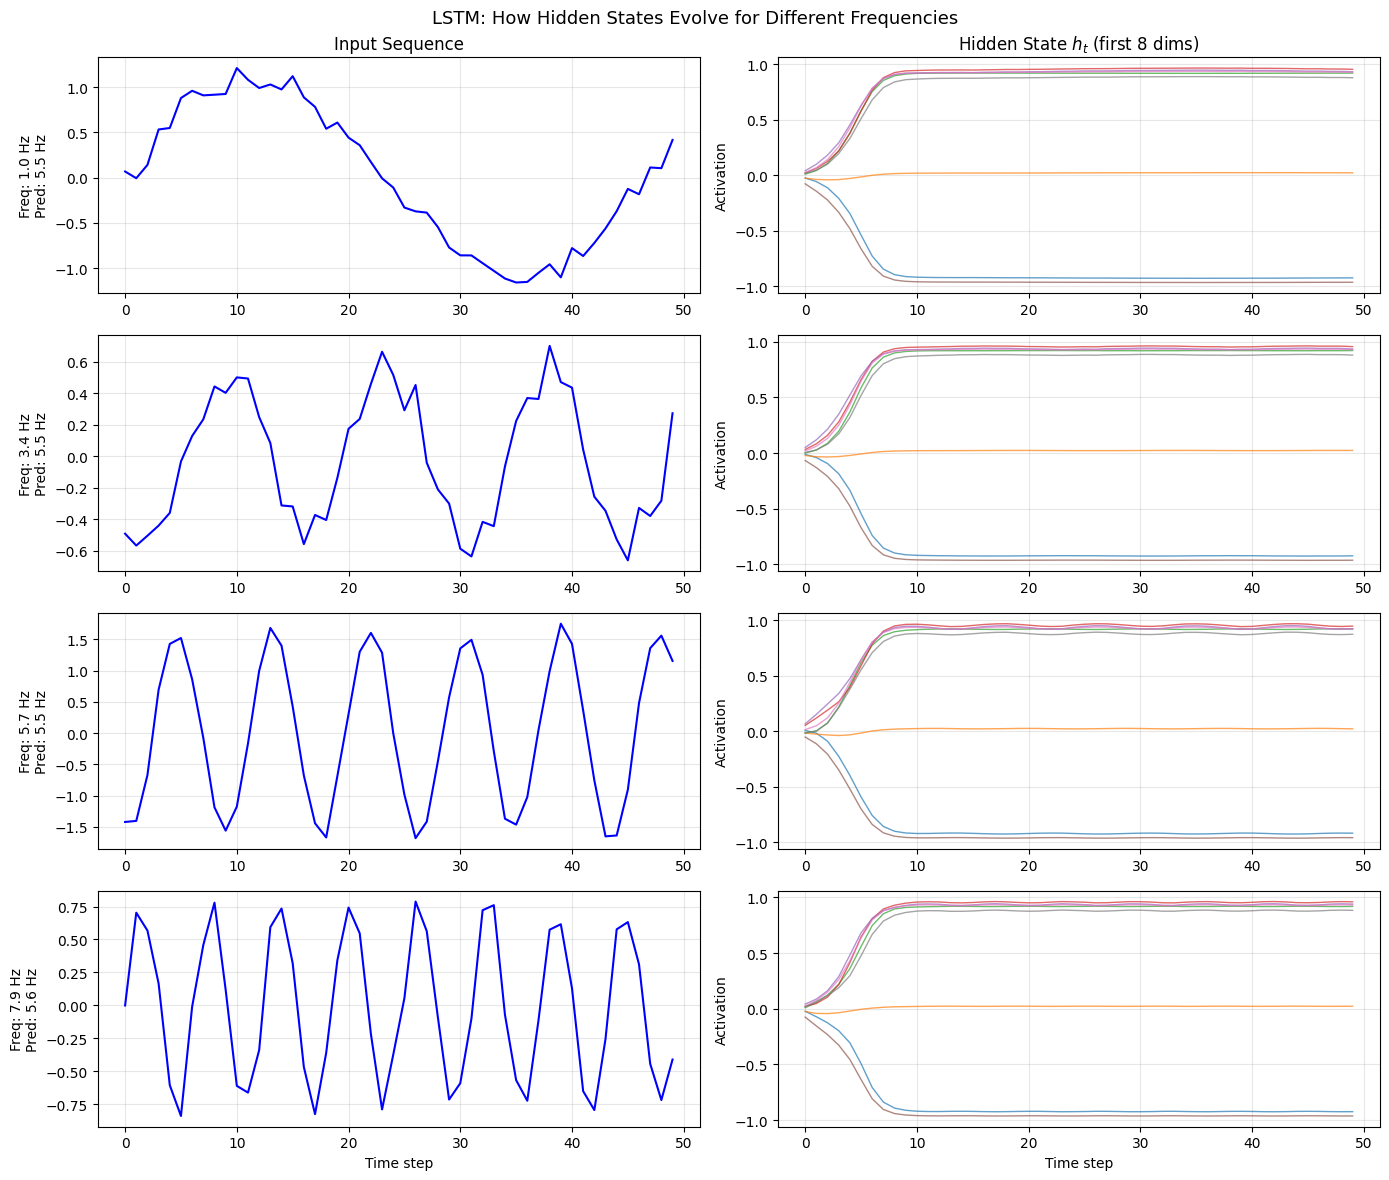

In [ ]:
# Pick 4 samples with different frequencies (low to high)
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

# Get test samples sorted by frequency
test_X_all = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
test_y_all = torch.stack([test_dataset[i][1] for i in range(len(test_dataset))])
sorted_indices = torch.argsort(test_y_all.squeeze())

# Pick samples from different frequency ranges
freq_ranges = [0, len(sorted_indices)//4, len(sorted_indices)//2, 3*len(sorted_indices)//4]
sample_indices = [sorted_indices[idx].item() for idx in freq_ranges]

model.eval()
for row, sample_idx in enumerate(sample_indices):
    sample = test_dataset[sample_idx][0].unsqueeze(0).to(device)  # (1, seq_len, 1)
    true_freq = test_dataset[sample_idx][1].item()

    # Extract hidden states at each time step
    with torch.no_grad():
        if MODEL_CHOICE == "RNN":
            h0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
            out, _ = model.rnn(sample, h0)
        elif MODEL_CHOICE == "LSTM":
            h0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
            c0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
            out, _ = model.lstm(sample, (h0, c0))
        elif MODEL_CHOICE == "GRU":
            h0 = torch.zeros(model.num_layers, 1, model.hidden_size).to(device)
            out, _ = model.gru(sample, h0)

        pred_freq = model(sample).item()

    hidden_states = out.squeeze(0).cpu().numpy()  # (seq_len, hidden_size)

    # Left: input sequence
    axes[row, 0].plot(sample.squeeze().cpu().numpy(), 'b-', linewidth=1.5)
    axes[row, 0].set_ylabel(f'Freq: {true_freq:.1f} Hz\nPred: {pred_freq:.1f} Hz')
    axes[row, 0].set_title('Input Sequence' if row == 0 else '')
    axes[row, 0].grid(True, alpha=0.3)

    # Right: hidden state evolution (show first 8 dimensions)
    for dim in range(min(8, hidden_size)):
        axes[row, 1].plot(hidden_states[:, dim], alpha=0.7, linewidth=1)
    axes[row, 1].set_title('Hidden State $h_t$ (first 8 dims)' if row == 0 else '')
    axes[row, 1].set_ylabel('Activation')
    axes[row, 1].grid(True, alpha=0.3)

axes[3, 0].set_xlabel('Time step')
axes[3, 1].set_xlabel('Time step')
plt.suptitle(f'{MODEL_CHOICE}: How Hidden States Evolve for Different Frequencies', fontsize=13)
plt.tight_layout()
plt.show()

---
## 10. Exercises

Try the following to deepen your understanding:

1. **Compare all three models**: Run this notebook 3 times with `MODEL_CHOICE = "RNN"`, `"LSTM"`, `"GRU"`. Which performs best on the regression task? Which trains fastest?

2. **Increase sequence length**: Change `seq_len` to 200 in `generate_sine_regression_data`. Does the Vanilla RNN struggle more than LSTM/GRU? (Relates to vanishing gradients)

3. **Stack more layers**: Set `num_layers = 2` or `3`. Does "Deep in Space" help regression performance?

4. **Change hidden size**: Try `hidden_size = 16` vs `128`. How does model capacity affect MAE and R²?

5. **Harder task**: Increase `noise_std` to `0.3` or `0.5` (more noise makes frequency harder to identify). How does each architecture handle noisy data?

6. **Different targets**: Modify the data generation to predict amplitude instead of frequency, or predict both (multi-output regression with `output_size=2`).

7. **Loss functions**: Try `nn.L1Loss()` (Mean Absolute Error) instead of `nn.MSELoss()`. How does it affect training?